# Misc

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, glob, re
import subprocess
from rainflow import extract_cycles

# Global config
DATA_DIR = r"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\solcast"

notebook_dir = os.getcwd()  # Gets test folder path
project_dir = os.path.dirname(notebook_dir)
os.chdir(project_dir)
os.getcwd()

'd:\\Jacky\\MATLAB\\Battery_ROI'

In [3]:
def load_data(folder, filename):
    file_path = os.path.join(folder, filename)
    assert os.path.exists(file_path), f"File not found: {file_path}"    
    data = pd.read_csv(file_path)
    return data

def compute_ces_aging_cost(
    soc_array,
    ces_capacities,
    N_100_fail=4300,
    kp=1.5,
    eta_c=0.9,
    eta_d=0.9
):
    """
    Compute total CES aging cost using rainflow cycle counting.
    """

    total_aging_cost = 0.0

    for i in range(soc_array.shape[0]):
        soc = soc_array[i, :]
        capacity = ces_capacities[i]

        cycles = extract_cycles(soc)

        for cycle in cycles:
            dod = cycle[0]      # range (0–1)
            count = cycle[2]    # cycle count (0.5 or 1.0)

            aging_cost = (
                (dod ** kp)
                * 1000
                * capacity
                / (N_100_fail * eta_c * eta_d)
            )

            total_aging_cost += aging_cost * count

    return total_aging_cost

In [4]:
solcast_data_folder = r"D:\Jacky\Python\ADMM_P2P_Python\data"

solcast_data = load_data(solcast_data_folder, "Solar_Solcast_year_utc8_MUM.csv")
solcast_peak_day = np.max(solcast_data, axis=1)
solcast_peak_mean = np.mean(solcast_peak_day)

solcast_peak_change = 100 * (solcast_peak_day - solcast_peak_mean) / solcast_peak_mean
solcast_idx = np.argsort(solcast_peak_change)
solcast_peak_change = solcast_peak_change[solcast_idx]


# Usage v2

In [4]:
# Example SOC preprocessing (same as MATLAB)
ces_lv_loc_subs      = r"MOMSA_code\Benchmark\p2p_CES\usage v2\Battery_Level_CES.csv"
bat_level   = pd.read_csv(ces_lv_loc_subs, header=None).to_numpy()[:,:-1].T

bat_level[0, :] /= 283.52
bat_level[1, :] /= 275.64

ces_capacities = [283.52, 275.64]

C_aging_total = compute_ces_aging_cost(
    soc_array=bat_level,
    ces_capacities=ces_capacities
)

print(f"Total CES Aging Cost: {C_aging_total:.2f}")
print(f"Matlab CES Aging Cost: 117.26")  # From MATLAB output for verification

Total CES Aging Cost: 117.26
Matlab CES Aging Cost: 117.26


In [5]:
data_folder = os.path.join(DATA_DIR, "usage_v2")

# find files and sort numerically
files = glob.glob(os.path.join(data_folder, "infeasible_*.txt"))
def _num(f):
    m = re.search(r'infeasible_(\d+)\.txt$', os.path.basename(f))
    return int(m.group(1)) if m else -1
files = sorted(files, key=_num)

collected = []
for f in files:
    with open(f, 'r', encoding='utf-8') as fh:
        lines = [L.strip() for L in fh if L.strip()]
    # try numeric conversion: floats first, fallback to strings
    try:
        arr = np.array([float(x) for x in lines])
    except ValueError:
        arr = np.array(lines, dtype=object)
    collected.append(arr)

# If all files have same length, stack to 2D array: shape (n_files, n_items)
if all(a.size == collected[0].size for a in collected):
    infeasible = np.vstack(collected)
else:
    infeasible = None  # inconsistent lengths; use 'collected' list instead

# quick checks
print("files found:", len(files))
print("first few files:", [os.path.basename(f) for f in files[:5]])
print("collected items:", len(collected))
if infeasible is not None:
    print("infeasible shape:", infeasible.shape)

files found: 364
first few files: ['infeasible_1.txt', 'infeasible_2.txt', 'infeasible_3.txt', 'infeasible_4.txt', 'infeasible_5.txt']
collected items: 364
infeasible shape: (364, 1)


In [6]:
#### Optimal Price Obtained ####
result_loc = 'MOMSA ranked limit usage v2 1'
result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\For paper\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
sol = 0
inputs = result[sol,:]

## Compute the revenue obtained from CES operation with the optimal price obtained
p2p_discount = inputs[2] * 100, inputs[3] * 100
close_discount = inputs[4] * 100, inputs[5] * 100
inputs[2] = inputs[0] * inputs[2]  # P2P charge price
inputs[3] = inputs[1] * inputs[3]  # P2P discharge price
inputs[4] = inputs[0] * inputs[4]  # Close charge price
inputs[5] = inputs[1] * inputs[5]  # Close discharge price

# Unpack prices
cost_c, cost_d, cost_c_p2p, cost_d_p2p, cost_c_close, cost_d_close = inputs
cost_c_t = np.empty(48, dtype=float)
cost_d_t = np.empty(48, dtype=float)
cost_c_t[:16]   = cost_c
cost_d_t[:16]   = cost_d
cost_c_t[16:37] = cost_c_p2p   # MATLAB 17:37 -> Python 16:37
cost_d_t[16:37] = cost_d_p2p
cost_c_t[37:48] = cost_c_close # MATLAB 38:48 -> Python 37:48
cost_d_t[37:48] = cost_d_close

print(f'Base/Start period price         : (${cost_c:.2f}, ${cost_d:.2f})')
print(f'P2P period price                : (${cost_c_p2p:.2f}, ${cost_d_p2p:.2f}), ({p2p_discount[0]:.2f}%, {p2p_discount[1]:.2f}%)')
print(f'Close period price              : (${cost_c_close:.2f}, ${cost_d_close:.2f}), ({close_discount[0]:.2f}%, {close_discount[1]:.2f}%)')
print("")

# Economic Indicators
CES_capacity = 500  # kWh
CES_cost_per_kWh = 400  # $/kWh
CES_initial_cost = 559160.47

TNB_revenue_CES_year = []
pros_CES_cost_year_list = []   # list of 1D arrays (one per day)
pros_log = []
discharge_year = []
aging_log = []

for i in range(1, 365):
    if infeasible[i-1] == 1:
        print(f"Day {i} is infeasible. Skipping calculations.")
        continue
    CESq_loc = os.path.join(data_folder, f"Charge_Discharge_{i}.csv")
    CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 

    ces_lv_loc_subs = os.path.join(data_folder, f"Battery_Level_CES_{i}.csv")
    bat_level = pd.read_csv(ces_lv_loc_subs, header=None).to_numpy()[:,:-1].T

    pros_cost_loc = os.path.join(data_folder, f"ProsumerCost_{i}.csv")
    pros_cost = pd.read_csv(pros_cost_loc, header=None).to_numpy()

    # Use broadcasting: (48,1) * (48,32) -> (48,32)
    charge_component = cost_c_t[:, None] * CESq            # applied to positive q values
    discharge_component = cost_d_t[:, None] * (-CESq)      # applied to negative q values (use -q)

    # Build cost_matrix: positive q -> charge_component, negative q -> discharge_component, else 0
    cost_matrix = np.where(CESq > 0, charge_component,
                        np.where(CESq < 0, discharge_component, 0.0))

    # Aging cost calculation
    bat_level[0, :] /= 283.52
    bat_level[1, :] /= 275.64

    ces_capacities = [283.52, 275.64]

    C_aging_total = compute_ces_aging_cost(
        soc_array=bat_level,
        ces_capacities=ces_capacities
    )
    
    # Aggregates
    TNB_revenue_CES = cost_matrix.sum()
    pros_CES_cost = cost_matrix.sum(axis=0)   # shape (32,)

    print('Day                             : ', i)
    print(f'TNB revenue from CES            : ${TNB_revenue_CES:.2f}')
    print(f'CES cost for prosumer (Avg)     : ${np.mean(pros_CES_cost):.2f}')
    print(f'CES aging cost                  : ${C_aging_total:.2f}')
    print('')

    pros_all_cost = pros_CES_cost + pros_cost.flatten()

    TNB_revenue_CES_year.append(TNB_revenue_CES)
    pros_CES_cost_year_list.append(pros_all_cost.copy()) 
    pros_log.append(np.mean(pros_all_cost))
    discharge_year.append(np.abs(np.sum(CESq[CESq < 0])))
    aging_log.append(C_aging_total)

# Calculate annual values (assuming 48 half-hour periods = 1 day)
annual_revenue = np.sum(TNB_revenue_CES_year)

# Calculate economic indicators
ROI = (annual_revenue / CES_initial_cost) * 100  # %
ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
payback_period = CES_initial_cost / annual_revenue  # years
LCOS = CES_initial_cost / (np.sum(discharge_year) * 20)  # $ per kWh over 20 years


# Print detailed results
print("\nEconomic Indicators:")
print(f"Initial Investment: ${CES_initial_cost:,.2f}")
print(f"Annual Revenue: ${annual_revenue:,.2f}")
print(f"ROI: {ROI:.2f}%")
print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
print(f"Payback Period: {payback_period:.2f} years")
print(f"LCOS: ${LCOS:.4f}/kWh")


Base/Start period price         : ($0.11, $0.44)
P2P period price                : ($0.05, $0.64), (46.70%, 144.45%)
Close period price              : ($0.05, $0.45), (52.22%, 101.38%)

Day                             :  1
TNB revenue from CES            : $72.70
CES cost for prosumer (Avg)     : $2.27
CES aging cost                  : $140.77

Day                             :  2
TNB revenue from CES            : $55.72
CES cost for prosumer (Avg)     : $1.74
CES aging cost                  : $110.65

Day                             :  3
TNB revenue from CES            : $81.69
CES cost for prosumer (Avg)     : $2.55
CES aging cost                  : $100.29

Day                             :  4
TNB revenue from CES            : $78.31
CES cost for prosumer (Avg)     : $2.45
CES aging cost                  : $133.83

Day                             :  5
TNB revenue from CES            : $106.63
CES cost for prosumer (Avg)     : $3.33
CES aging cost                  : $140.37

Day     

In [7]:
print('TNB revenue from CES service')
print('---------------------------------------')
print('Min Revenue  : $', format(np.min(TNB_revenue_CES_year), ',.2f'))
print('Max Revenue  : $', format(np.max(TNB_revenue_CES_year), ',.2f'))
print('Mean Revenue : $', format(np.mean(TNB_revenue_CES_year), ',.2f'))
print('Std Revenue  : $', format(np.std(TNB_revenue_CES_year), ',.2f'))
print('')
print('Prosumer CES cost')
print('---------------------------------------')
print('Min Cost     : $', format(np.min(pros_CES_cost_year_list), ',.2f'))  
print('Max Cost     : $', format(np.max(pros_CES_cost_year_list), ',.2f'))
print('Mean Cost    : $', format(np.mean(pros_CES_cost_year_list), ',.2f'))
print('Std Cost     : $', format(np.std(pros_CES_cost_year_list), ',.2f'))

TNB revenue from CES service
---------------------------------------
Min Revenue  : $ 0.43
Max Revenue  : $ 149.62
Mean Revenue : $ 95.01
Std Revenue  : $ 31.42

Prosumer CES cost
---------------------------------------
Min Cost     : $ 3.11
Max Cost     : $ 11.25
Mean Cost    : $ 6.60
Std Cost     : $ 1.95


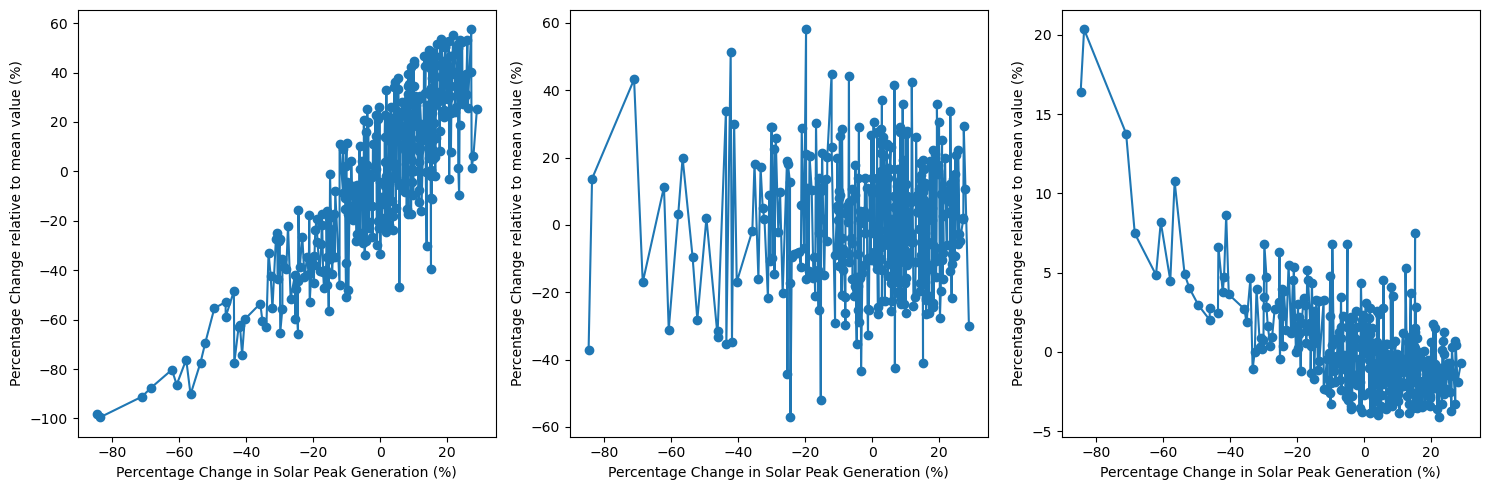

In [8]:
tnb_revenue_mean = np.mean(TNB_revenue_CES_year)
tnb_revenue_change = 100 * (TNB_revenue_CES_year - tnb_revenue_mean) / tnb_revenue_mean

pros_cost_mean = np.mean(pros_log)
pros_cost_change = 100 * (np.array(pros_log) - pros_cost_mean) / pros_cost_mean

aging_mean = np.mean(aging_log)
aging_change = 100 * (np.array(aging_log) - aging_mean) / aging_mean

tnb_revenue_change = tnb_revenue_change[solcast_idx]
aging_change = aging_change[solcast_idx]
pros_cost_change = pros_cost_change[solcast_idx]

# Figure
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(solcast_peak_change, tnb_revenue_change, marker='o')
# axs.plot(solcast_peak_change, aging_change, marker='o')
# axs.plot(solcast_peak_change, pros_cost_change, marker='o')
axs[0].set_xlabel('Percentage Change in Solar Peak Generation (%)')
axs[0].set_ylabel('Percentage Change relative to mean value (%)')

# axs[0].plot(solcast_peak_change, tnb_revenue_change, marker='o')
axs[1].plot(solcast_peak_change, aging_change, marker='o')
# axs.plot(solcast_peak_change, pros_cost_change, marker='o')
axs[1].set_xlabel('Percentage Change in Solar Peak Generation (%)')
axs[1].set_ylabel('Percentage Change relative to mean value (%)')

# axs[0].plot(solcast_peak_change, tnb_revenue_change, marker='o')
# axs.plot(solcast_peak_change, aging_change, marker='o')
axs[2].plot(solcast_peak_change, pros_cost_change, marker='o')
axs[2].set_xlabel('Percentage Change in Solar Peak Generation (%)')
axs[2].set_ylabel('Percentage Change relative to mean value (%)')
# plt.legend(['TNB Revenue Change', 'CES Aging Cost Change', 'Prosumer CES Cost Change'])
plt.tight_layout()
plt.show()

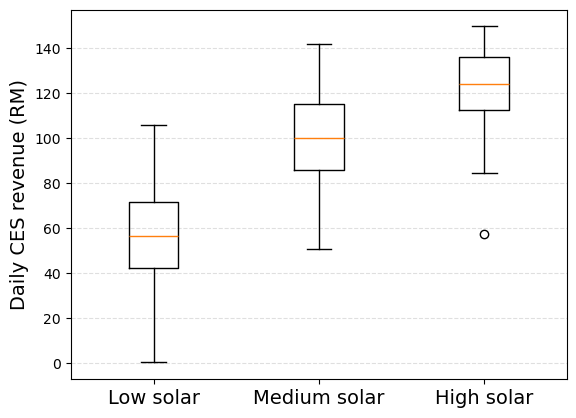

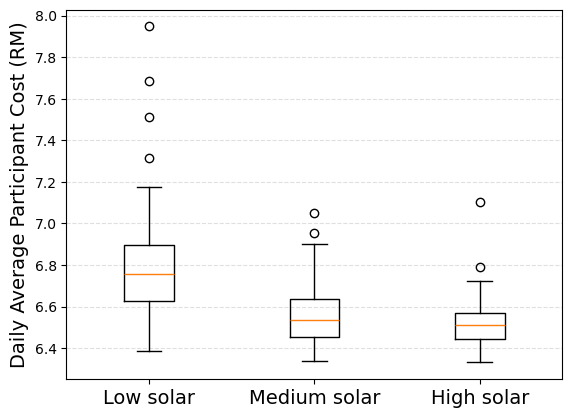

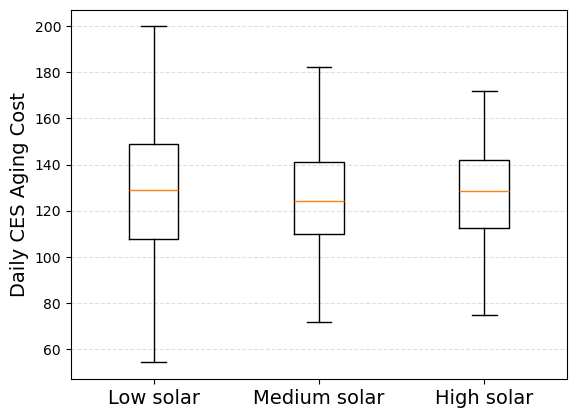

In [9]:
tnb_usage_log, pros_usage_log, aging_usage_log = TNB_revenue_CES_year, pros_log, aging_log

q = np.quantile(solcast_peak_day, [0.25, 0.75])
low = solcast_peak_day <= q[0]
mid = (solcast_peak_day > q[0]) & (solcast_peak_day < q[1])
high = solcast_peak_day >= q[1]

fig = plt.figure()
plt.boxplot([
    np.array(TNB_revenue_CES_year)[low],
    np.array(TNB_revenue_CES_year)[mid],
    np.array(TNB_revenue_CES_year)[high]
], tick_labels=['Low solar', 'Medium solar', 'High solar'])

plt.xticks(fontsize=14)
plt.ylabel('Daily CES revenue (RM)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('TNB_revenue_boxplot_usage.svg', dpi=300)
plt.show()

fig = plt.figure()
plt.boxplot([
    np.array(pros_log)[low],
    np.array(pros_log)[mid],
    np.array(pros_log)[high]
], tick_labels=['Low solar', 'Medium solar', 'High solar'])

plt.xticks(fontsize=14)
plt.ylabel('Daily Average Participant Cost (RM)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('Prosumer_cost_boxplot_usage.svg', dpi=300)
plt.show()

fig = plt.figure()
plt.boxplot([
    np.array(aging_log)[low],
    np.array(aging_log)[mid],
    np.array(aging_log)[high]
], tick_labels=['Low solar', 'Medium solar', 'High solar'])

plt.xticks(fontsize=14)
plt.ylabel('Daily CES Aging Cost', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('CES_aging_cost_boxplot_usage.svg', dpi=300)
plt.show()


# Subscription V3

In [10]:
# Example SOC preprocessing (same as MATLAB)
ces_lv_loc_subs      = r"MOMSA_code\Benchmark\p2p_CES\subs v3\Battery_Level_CES.csv"
bat_level   = pd.read_csv(ces_lv_loc_subs, header=None).to_numpy()[:,:-1].T

bat_level[0, :] /= 283.52
bat_level[1, :] /= 275.64

ces_capacities = [283.52, 275.64]

C_aging_total = compute_ces_aging_cost(
    soc_array=bat_level,
    ces_capacities=ces_capacities
)

print(f"Total CES Aging Cost: {C_aging_total:.2f}")
print(f"Matlab CES Aging Cost: 117.90")  # From MATLAB output for verification

Total CES Aging Cost: 117.90
Matlab CES Aging Cost: 117.90


In [11]:
data_folder = os.path.join(DATA_DIR, "subs_v3")
print("\nLoading data from:", data_folder)

# find files and sort numerically
files = glob.glob(os.path.join(data_folder, "infeasible_*.txt"))
def _num(f):
    m = re.search(r'infeasible_(\d+)\.txt$', os.path.basename(f))
    return int(m.group(1)) if m else -1
files = sorted(files, key=_num)

collected = []
for f in files:
    with open(f, 'r', encoding='utf-8') as fh:
        lines = [L.strip() for L in fh if L.strip()]
    # try numeric conversion: floats first, fallback to strings
    try:
        arr = np.array([float(x) for x in lines])
    except ValueError:
        arr = np.array(lines, dtype=object)
    collected.append(arr)

# If all files have same length, stack to 2D array: shape (n_files, n_items)
if all(a.size == collected[0].size for a in collected):
    infeasible = np.vstack(collected)
else:
    infeasible = None  # inconsistent lengths; use 'collected' list instead

# quick checks
print("files found:", len(files))
print("first few files:", [os.path.basename(f) for f in files[:5]])
print("collected items:", len(collected))
if infeasible is not None:
    print("infeasible shape:", infeasible.shape)


Loading data from: D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\solcast\subs_v3
files found: 364
first few files: ['infeasible_1.txt', 'infeasible_2.txt', 'infeasible_3.txt', 'infeasible_4.txt', 'infeasible_5.txt']
collected items: 364
infeasible shape: (364, 1)


In [12]:
#### Optimal Price Obtained ####
result_loc = 'MOMSA ranked unlimit subsc v4 1'
result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\For paper\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
sol = 0

## Compute the revenue obtained from CES operation with the optimal price obtained
subs_price = result[sol,0]
capacity_subs = result[sol,1:]
print(f'Average Subscribed Capacity per Prosumer: {np.mean(capacity_subs):.2f} kWh')

# Economic Indicators
CES_capacity = 500  # kWh
CES_cost_per_kWh = 400  # $/kWh
CES_initial_cost = 559160.47

discharge_year = []
TNB_revenue_CES_year = []
pros_log = []
aging_log = []

for i in range(1, 365):
    if infeasible[i-1] == 1:
        print(f"Day {i} is infeasible. Skipping calculations.")
        continue
    CESq_loc = os.path.join(data_folder, f"Charge_Discharge_{i}.csv")
    CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 

    discharge_year.append(np.abs(np.sum(CESq[CESq < 0])))

    # Aging cost calculation
    ces_lv_loc_subs = os.path.join(data_folder, f"Battery_Level_CES_{i}.csv")
    bat_level = pd.read_csv(ces_lv_loc_subs, header=None).to_numpy()[:,:-1].T

    pros_cost_loc = os.path.join(data_folder, f"ProsumerCost_{i}.csv")
    pros_cost = pd.read_csv(pros_cost_loc, header=None).to_numpy()

    bat_level[0, :] /= 283.52
    bat_level[1, :] /= 275.64

    ces_capacities = [283.52, 275.64]

    C_aging_total = compute_ces_aging_cost(
        soc_array=bat_level,
        ces_capacities=ces_capacities
    )
    pros_CES_cost = subs_price * capacity_subs / 30
    TNB_revenue_CES = np.sum(pros_CES_cost)
    pros_all_cost = pros_CES_cost + pros_cost.flatten()

    TNB_revenue_CES_year.append(TNB_revenue_CES)
    pros_log.append(np.mean(pros_all_cost))
    aging_log.append(C_aging_total)
    
    print('Day                             : ', i)
    print(f'TNB revenue from CES            : ${TNB_revenue_CES:.2f}')
    print(f'CES cost for prosumer (Avg)     : ${np.mean(pros_CES_cost):.2f}')
    print(f'CES aging cost                  : ${C_aging_total:.2f}')
    print('')

pros_CES_cost_year = subs_price * capacity_subs * 12 
TNB_revenue_CES_annual = np.sum(pros_CES_cost_year)

# Calculate annual values (assuming 48 half-hour periods = 1 day)
annual_revenue = np.sum(TNB_revenue_CES_annual)

# Calculate economic indicators
ROI = (annual_revenue / CES_initial_cost) * 100  # %
ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
payback_period = CES_initial_cost / annual_revenue  # years
LCOS = CES_initial_cost / (np.sum(discharge_year) * 20)  # $ per kWh over 20 years

# Print detailed results
print("Economic Indicators:")
print(f"Initial Investment: ${CES_initial_cost:,.2f}")
print(f"Annual Revenue: ${annual_revenue:,.2f}")
print(f"ROI: {ROI:.2f}%")
print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
print(f"Payback Period: {payback_period:.2f} years")
print(f"LCOS: ${LCOS:.4f}/kWh")


Average Subscribed Capacity per Prosumer: 17.46 kWh
Day                             :  1
TNB revenue from CES            : $184.69
CES cost for prosumer (Avg)     : $5.77
CES aging cost                  : $138.60



Day                             :  2
TNB revenue from CES            : $184.69
CES cost for prosumer (Avg)     : $5.77
CES aging cost                  : $114.76

Day                             :  3
TNB revenue from CES            : $184.69
CES cost for prosumer (Avg)     : $5.77
CES aging cost                  : $107.52

Day                             :  4
TNB revenue from CES            : $184.69
CES cost for prosumer (Avg)     : $5.77
CES aging cost                  : $162.16

Day                             :  5
TNB revenue from CES            : $184.69
CES cost for prosumer (Avg)     : $5.77
CES aging cost                  : $169.65

Day                             :  6
TNB revenue from CES            : $184.69
CES cost for prosumer (Avg)     : $5.77
CES aging cost                  : $146.82

Day                             :  7
TNB revenue from CES            : $184.69
CES cost for prosumer (Avg)     : $5.77
CES aging cost                  : $143.27

Day                         

In [13]:
TNB_revenue_CES = np.sum(subs_price * capacity_subs)
pros_CES_cost = subs_price * capacity_subs

print(f'Subscription price per kWh: $ {subs_price:.2f}')
print(f'\nTNB revenue from CES service')
print('---------------------------------------')
print('Daily (Avg)  : $ ', format((TNB_revenue_CES / 30), ',.2f'))
print('Monthly (Avg): $ ', format((TNB_revenue_CES), ',.2f'))
print('Yearly       : $ ', format((TNB_revenue_CES_annual), ',.2f'))
print('\nProsumer CES cost')
print('---------------------------------------')
print('Min Cost     : $', format(np.min(pros_CES_cost), ',.2f'))  
print('Max Cost     : $', format(np.max(pros_CES_cost), ',.2f'))
print('Mean Cost    : $', format(np.mean(pros_CES_cost), ',.2f'))
print('Std Cost     : $', format(np.std(pros_CES_cost), ',.2f'))

Subscription price per kWh: $ 9.92

TNB revenue from CES service
---------------------------------------
Daily (Avg)  : $  184.69
Monthly (Avg): $  5,540.57
Yearly       : $  66,486.85

Prosumer CES cost
---------------------------------------
Min Cost     : $ 22.36
Max Cost     : $ 278.41
Mean Cost    : $ 173.14
Std Cost     : $ 76.89


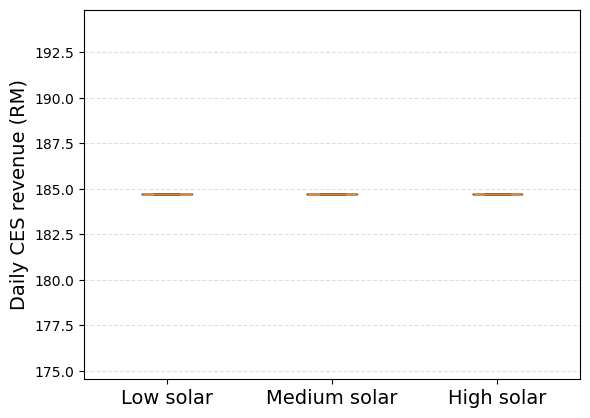

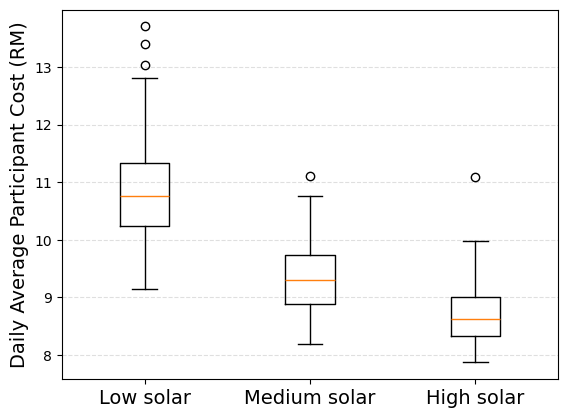

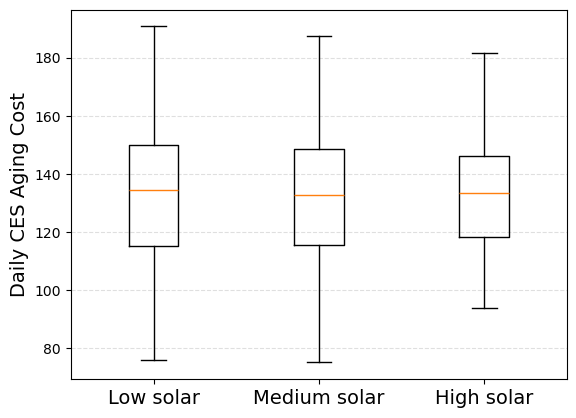

In [14]:
q = np.quantile(solcast_peak_day, [0.25, 0.75])
low = solcast_peak_day <= q[0]
mid = (solcast_peak_day > q[0]) & (solcast_peak_day < q[1])
high = solcast_peak_day >= q[1]

fig = plt.figure()
plt.boxplot([
    np.array(TNB_revenue_CES_year)[low],
    np.array(TNB_revenue_CES_year)[mid],
    np.array(TNB_revenue_CES_year)[high]
], tick_labels=['Low solar', 'Medium solar', 'High solar'])

plt.xticks(fontsize=14)
plt.ylabel('Daily CES revenue (RM)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('TNB_revenue_boxplot_subs.svg', dpi=300)
plt.show()

fig = plt.figure()
plt.boxplot([
    np.array(pros_log)[low],
    np.array(pros_log)[mid],
    np.array(pros_log)[high]
], tick_labels=['Low solar', 'Medium solar', 'High solar'])

plt.xticks(fontsize=14)
plt.ylabel('Daily Average Participant Cost (RM)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('Prosumer_cost_boxplot_subs.svg', dpi=300)
plt.show()

fig = plt.figure()
plt.boxplot([
    np.array(aging_log)[low],
    np.array(aging_log)[mid],
    np.array(aging_log)[high]
], tick_labels=['Low solar', 'Medium solar', 'High solar'])

plt.xticks(fontsize=14)
plt.ylabel('Daily CES Aging Cost', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('CES_aging_cost_boxplot_subs.svg', dpi=300)
plt.show()


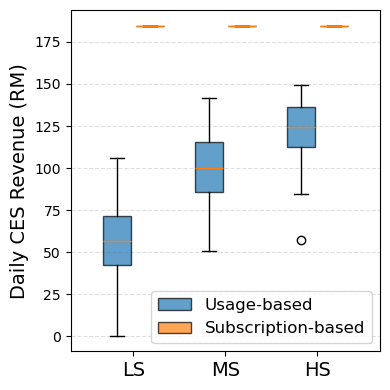

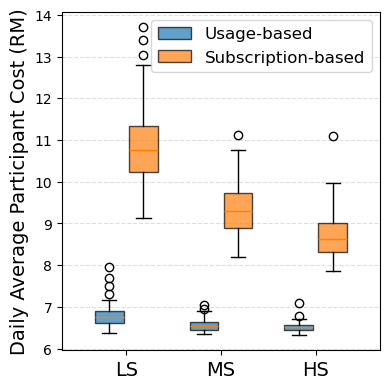

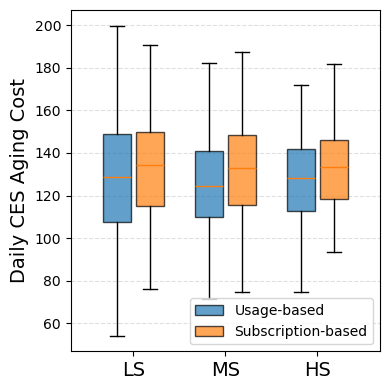

In [26]:
tnb_usage_log, pros_usage_log, aging_usage_log = np.array(tnb_usage_log), np.array(pros_usage_log), np.array(aging_usage_log)
TNB_revenue_CES_year, pros_log, aging_log = np.array(TNB_revenue_CES_year), np.array(pros_log), np.array(aging_log)

# Positions
base_pos = np.array([1, 2, 3])
offset = 0.18

pos_usage = base_pos - offset
pos_subs  = base_pos + offset

fig, ax = plt.subplots(figsize=(4, 4))

# Boxplots
bp1 = ax.boxplot([
    tnb_usage_log[low],
    tnb_usage_log[mid],
    tnb_usage_log[high]],
    positions=pos_usage,
    widths=0.3,
    patch_artist=True,
    showfliers=True
)

bp2 = ax.boxplot([
    TNB_revenue_CES_year[low],
    TNB_revenue_CES_year[mid],
    TNB_revenue_CES_year[high]],
    positions=pos_subs,
    widths=0.3,
    patch_artist=True,
    showfliers=True
)

# Colors
for box in bp1['boxes']:
    box.set(facecolor='#1f77b4', alpha=0.7)  # Usage

for box in bp2['boxes']:
    box.set(facecolor='#ff7f0e', alpha=0.7)  # Subscription

# Axis formatting
ax.set_xticks(base_pos)
ax.set_xticklabels(['LS', 'MS', 'HS'], fontsize=14)
ax.set_ylabel('Daily CES Revenue (RM)', fontsize=14)

ax.grid(axis='y', linestyle='--', alpha=0.4)

# Legend (manual, clean)
ax.legend(
    [bp1['boxes'][0], bp2['boxes'][0]],
    ['Usage-based', 'Subscription-based'],
    # loc='upper left',
    fontsize=12
)

plt.tight_layout()
plt.savefig('TNB_revenue_boxplot.svg', dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))

# Boxplots
bp1 = ax.boxplot([
    pros_usage_log[low],
    pros_usage_log[mid],
    pros_usage_log[high]],
    positions=pos_usage,
    widths=0.3,
    patch_artist=True,
    showfliers=True
)

bp2 = ax.boxplot([
    pros_log[low],
    pros_log[mid],
    pros_log[high]],
    positions=pos_subs,
    widths=0.3,
    patch_artist=True,
    showfliers=True
)

# Colors
for box in bp1['boxes']:
    box.set(facecolor='#1f77b4', alpha=0.7)  # Usage

for box in bp2['boxes']:
    box.set(facecolor='#ff7f0e', alpha=0.7)  # Subscription

# Axis formatting
ax.set_xticks(base_pos)
ax.set_xticklabels(['LS', 'MS', 'HS'], fontsize=14)
ax.set_ylabel('Daily Average Participant Cost (RM)', fontsize=14)

ax.grid(axis='y', linestyle='--', alpha=0.4)

# Legend (manual, clean)
ax.legend(
    [bp1['boxes'][0], bp2['boxes'][0]],
    ['Usage-based', 'Subscription-based'],
    # loc='upper left',
    fontsize=12
)

plt.tight_layout()
plt.savefig('Prosumer_cost_boxplot.svg', dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))

# Boxplots
bp1 = ax.boxplot([
    aging_usage_log[low],
    aging_usage_log[mid],
    aging_usage_log[high]],
    positions=pos_usage,
    widths=0.3,
    patch_artist=True,
    showfliers=True
)

bp2 = ax.boxplot([
    aging_log[low],
    aging_log[mid],
    aging_log[high]],
    positions=pos_subs,
    widths=0.3,
    patch_artist=True,
    showfliers=True
)

# Colors
for box in bp1['boxes']:
    box.set(facecolor='#1f77b4', alpha=0.7)  # Usage

for box in bp2['boxes']:
    box.set(facecolor='#ff7f0e', alpha=0.7)  # Subscription

# Axis formatting
ax.set_xticks(base_pos)
ax.set_xticklabels(['LS', 'MS', 'HS'], fontsize=14)
ax.set_ylabel('Daily CES Aging Cost', fontsize=14)

ax.grid(axis='y', linestyle='--', alpha=0.4)

# Legend (manual, clean)
ax.legend(
    [bp1['boxes'][0], bp2['boxes'][0]],
    ['Usage-based', 'Subscription-based'],
    loc='lower right',
    fontsize=10
)

plt.tight_layout()
plt.savefig('CES_aging_cost_boxplot.svg', dpi=300)
plt.show()

# Sensitivity Analysis

In [5]:
def infesible_data_loader(data_folder):
    # find files and sort numerically
    files = glob.glob(os.path.join(data_folder, "infeasible_*.txt"))
    def _num(f):
        m = re.search(r'infeasible_(\d+)\.txt$', os.path.basename(f))
        return int(m.group(1)) if m else -1
    files = sorted(files, key=_num)

    collected = []
    for f in files:
        with open(f, 'r', encoding='utf-8') as fh:
            lines = [L.strip() for L in fh if L.strip()]
        # try numeric conversion: floats first, fallback to strings
        try:
            arr = np.array([float(x) for x in lines])
        except ValueError:
            arr = np.array(lines, dtype=object)
        collected.append(arr)

    # If all files have same length, stack to 2D array: shape (n_files, n_items)
    if all(a.size == collected[0].size for a in collected):
        infeasible = np.vstack(collected)
    else:
        infeasible = None  # inconsistent lengths; use 'collected' list instead

    # # quick checks
    # print("files found:", len(files))
    # print("first few files:", [os.path.basename(f) for f in files[:5]])
    # print("collected items:", len(collected))
    # if infeasible is not None:
    #     print("infeasible shape:", infeasible.shape)
    return infeasible

In [6]:
# Usage
change_log = []
roi_log = []
lcos_log = []
ROI_lifetime_log = []
payback_period_log = []

for i in range(20):
    change = (i / 2 * 0.1) - 50 / 100
    change_log.append(change)
    data_folder = rf"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\solcast\usage_v2\run_{change:.2f}"
    infeasible = infesible_data_loader(data_folder)
    
    #### Optimal Price Obtained ####
    result_loc = 'MOMSA ranked limit usage v2 1'
    result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\For paper\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
    sol = 0
    inputs = result[sol,:]
    # for sensitivity analysis
    inputs[0] = inputs[0] * (1 + change)
    inputs[1] = inputs[1] * (1 + change)
    
    ## Compute the revenue obtained from CES operation with the optimal price obtained
    p2p_discount = inputs[2] * 100, inputs[3] * 100
    close_discount = inputs[4] * 100, inputs[5] * 100
    inputs[2] = inputs[0] * inputs[2]  # P2P charge price
    inputs[3] = inputs[1] * inputs[3]  # P2P discharge price
    inputs[4] = inputs[0] * inputs[4]  # Close charge price
    inputs[5] = inputs[1] * inputs[5]  # Close discharge price

    # Unpack prices
    cost_c, cost_d, cost_c_p2p, cost_d_p2p, cost_c_close, cost_d_close = inputs
    cost_c_t = np.empty(48, dtype=float)
    cost_d_t = np.empty(48, dtype=float)
    cost_c_t[:16]   = cost_c
    cost_d_t[:16]   = cost_d
    cost_c_t[16:37] = cost_c_p2p   # MATLAB 17:37 -> Python 16:37
    cost_d_t[16:37] = cost_d_p2p
    cost_c_t[37:48] = cost_c_close # MATLAB 38:48 -> Python 37:48
    cost_d_t[37:48] = cost_d_close

    print(f'Base/Start period price         : (${cost_c:.2f}, ${cost_d:.2f})')
    print(f'P2P period price                : (${cost_c_p2p:.2f}, ${cost_d_p2p:.2f}), ({p2p_discount[0]:.2f}%, {p2p_discount[1]:.2f}%)')
    print(f'Close period price              : (${cost_c_close:.2f}, ${cost_d_close:.2f}), ({close_discount[0]:.2f}%, {close_discount[1]:.2f}%)')
    print("")

    # Economic Indicators
    CES_capacity = 500  # kWh
    CES_cost_per_kWh = 400  # $/kWh
    CES_initial_cost = 559160.47

    TNB_revenue_CES_year = []
    pros_CES_cost_year_list = []   # list of 1D arrays (one per day)
    pros_log = []
    discharge_year = []
    aging_log = []

    for i in range(1, 365):
        if infeasible[i-1] == 1:
            print(f"Day {i} is infeasible. Skipping calculations.")
            continue
        CESq_loc = os.path.join(data_folder, f"Charge_Discharge_{i}.csv")
        CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 

        ces_lv_loc_subs = os.path.join(data_folder, f"Battery_Level_CES_{i}.csv")
        bat_level = pd.read_csv(ces_lv_loc_subs, header=None).to_numpy()[:,:-1].T

        # Use broadcasting: (48,1) * (48,32) -> (48,32)
        charge_component = cost_c_t[:, None] * CESq            # applied to positive q values
        discharge_component = cost_d_t[:, None] * (-CESq)      # applied to negative q values (use -q)

        # Build cost_matrix: positive q -> charge_component, negative q -> discharge_component, else 0
        cost_matrix = np.where(CESq > 0, charge_component,
                            np.where(CESq < 0, discharge_component, 0.0))

        # Aging cost calculation
        bat_level[0, :] /= 283.52
        bat_level[1, :] /= 275.64

        ces_capacities = [283.52, 275.64]

        C_aging_total = compute_ces_aging_cost(
            soc_array=bat_level,
            ces_capacities=ces_capacities
        )
        
        # Aggregates
        TNB_revenue_CES = cost_matrix.sum()
        pros_CES_cost = cost_matrix.sum(axis=0)   # shape (32,)

        # print('Day                             : ', i)
        # print(f'TNB revenue from CES            : ${TNB_revenue_CES:.2f}')
        # print(f'CES cost for prosumer (Avg)     : ${np.mean(pros_CES_cost):.2f}')
        # print(f'CES aging cost                  : ${C_aging_total:.2f}')
        # print('')
        
        TNB_revenue_CES_year.append(TNB_revenue_CES)
        pros_CES_cost_year_list.append(pros_CES_cost.copy()) 
        pros_log.append(np.mean(pros_CES_cost))
        discharge_year.append(np.abs(np.sum(CESq[CESq < 0])))
        aging_log.append(C_aging_total)

    # Calculate annual values (assuming 48 half-hour periods = 1 day)
    annual_revenue = np.sum(TNB_revenue_CES_year)

    # Calculate economic indicators
    ROI = (annual_revenue / CES_initial_cost) * 100  # %
    ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
    payback_period = CES_initial_cost / annual_revenue  # years
    LCOS = CES_initial_cost / (np.sum(discharge_year) * 20)  # $ per kWh over 20 years

    roi_log.append(ROI)
    lcos_log.append(LCOS)
    ROI_lifetime_log.append(ROI_lifetime)
    payback_period_log.append(payback_period)

    # Print detailed results
    print(f"\nRun: {change:.2f}")
    print("================================")
    print("Economic Indicators:")
    print(f"Initial Investment: ${CES_initial_cost:,.2f}")
    print(f"Annual Revenue: ${annual_revenue:,.2f}")
    print(f"ROI: {ROI:.2f}%")
    print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
    print(f"Payback Period: {payback_period:.2f} years")
    print(f"LCOS: ${LCOS:.4f}/kWh")

Base/Start period price         : ($0.05, $0.22)
P2P period price                : ($0.02, $0.32), (46.70%, 144.45%)
Close period price              : ($0.03, $0.22), (52.22%, 101.38%)


Run: -0.50
Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $19,225.21
ROI: 3.44%
ROI (Lifetime): 68.76%
Payback Period: 29.08 years
LCOS: $0.3581/kWh
Base/Start period price         : ($0.06, $0.24)
P2P period price                : ($0.03, $0.35), (46.70%, 144.45%)
Close period price              : ($0.03, $0.25), (52.22%, 101.38%)


Run: -0.45
Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $21,146.91
ROI: 3.78%
ROI (Lifetime): 75.64%
Payback Period: 26.44 years
LCOS: $0.3581/kWh
Base/Start period price         : ($0.06, $0.27)
P2P period price                : ($0.03, $0.38), (46.70%, 144.45%)
Close period price              : ($0.03, $0.27), (52.22%, 101.38%)


Run: -0.40
Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $23,069.36
ROI: 4

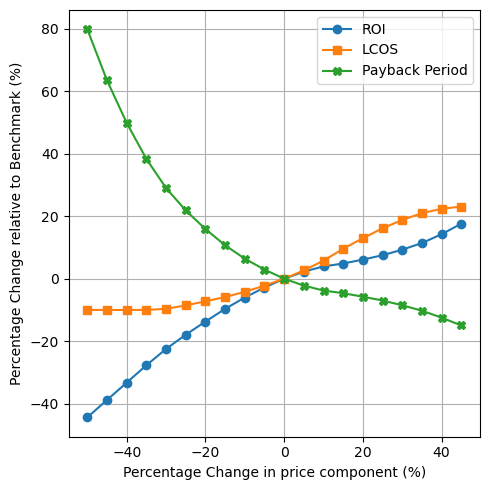

In [7]:
change_log, roi_log, lcos_log, ROI_lifetime_log, payback_period_log = np.array(change_log), np.array(roi_log), np.array(lcos_log), np.array(ROI_lifetime_log), np.array(payback_period_log)
bench_idx = np.where(change_log ==  0)[0]
bench_values = {
    'ROI': roi_log[bench_idx][0],
    'LCOS': lcos_log[bench_idx][0],
    'ROI_lifetime': ROI_lifetime_log[bench_idx][0],
    'payback_period': payback_period_log[bench_idx][0]
}

# percentage change from benchmark
roi_change = 100 * (roi_log - bench_values['ROI']) / bench_values['ROI']
lcos_change = 100 * (lcos_log - bench_values['LCOS']) / bench_values['LCOS']
ROI_lifetime_change = 100 * (ROI_lifetime_log - bench_values['ROI_lifetime']) / bench_values['ROI_lifetime']
payback_period_change = 100 * (payback_period_log - bench_values['payback_period']) / bench_values['payback_period']

# Plotting
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(change_log * 100, roi_change, marker='o')
ax.plot(change_log * 100, lcos_change, marker='s')
# ax.plot(change_log * 100, ROI_lifetime_change, marker='^')
ax.plot(change_log * 100, payback_period_change, marker='X')

# ax.legend(['ROI', 'LCOS', 'ROI (Lifetime)', 'Payback Period'])
ax.legend(['ROI', 'LCOS', 'Payback Period'])
ax.set_xlabel('Percentage Change in price component (%)')
ax.set_ylabel('Percentage Change relative to Benchmark (%)')

plt.grid()
plt.tight_layout()
plt.savefig('sens_price_usage.svg', dpi=300)
plt.show()

In [8]:
payback_period_change

array([ 79.84939993,  63.50584504,  49.88028714,  38.34899146,
        29.02808996,  21.85529831,  15.90650238,  10.68819993,
         6.41644739,   2.9107348 ,   0.        ,  -2.21523419,
        -3.79027592,  -4.63976366,  -5.77492242,  -6.98949351,
        -8.51052725, -10.25239314, -12.47152886, -14.98461045])

In [ ]:
# subscription sensitivity analysis
change_log = []
roi_log = []
lcos_log = []
ROI_lifetime_log = []
payback_period_log = []

for i in range(20):
    change = (i / 2 * 0.1) - 50 / 100
    change_log.append(change)
    data_folder = rf"D:\Jacky\MATLAB\Battery_ROI\MOMSA_code\Benchmark\solcast\subs_v3\run_{change:.2f}"
    infeasible = infesible_data_loader(data_folder)
    
    #### Optimal Price Obtained ####
    result_loc = 'MOMSA ranked unlimit subsc v4 1'
    result = np.array(pd.read_excel(fr"D:\Jacky\Data Output\Battery ROI\For paper\{result_loc}.xlsx", sheet_name="Sheet1", header=None))
    sol = 0
    result[sol,0] = result[sol,0] * (1 + change)

    ## Compute the revenue obtained from CES operation with the optimal price obtained
    subs_price = result[sol,0]
    capacity_subs = result[sol,1:]
    # print(f'Average Subscribed Capacity per Prosumer: {np.mean(capacity_subs):.2f} kWh')

    # Economic Indicators
    CES_capacity = 500  # kWh
    CES_cost_per_kWh = 400  # $/kWh
    CES_initial_cost = 559160.47

    discharge_year = []
    TNB_revenue_CES_year = []
    pros_log = []
    aging_log = []

    for i in range(1, 365):
        if infeasible[i-1] == 1:
            print(f"Day {i} is infeasible. Skipping calculations.")
            continue
        CESq_loc = os.path.join(data_folder, f"Charge_Discharge_{i}.csv")
        CESq = pd.read_csv(CESq_loc, header=None).to_numpy()[:,:-1] 

        discharge_year.append(np.abs(np.sum(CESq[CESq < 0])))

        # Aging cost calculation
        ces_lv_loc_subs = os.path.join(data_folder, f"Battery_Level_CES_{i}.csv")
        bat_level = pd.read_csv(ces_lv_loc_subs, header=None).to_numpy()[:,:-1].T

        bat_level[0, :] /= 283.52
        bat_level[1, :] /= 275.64

        ces_capacities = [283.52, 275.64]

        C_aging_total = compute_ces_aging_cost(
            soc_array=bat_level,
            ces_capacities=ces_capacities
        )
        pros_CES_cost = subs_price * capacity_subs / 30
        TNB_revenue_CES = np.sum(pros_CES_cost)

        TNB_revenue_CES_year.append(TNB_revenue_CES)
        pros_log.append(np.mean(pros_CES_cost))
        aging_log.append(C_aging_total)
        
        # print('Day                             : ', i)
        # print(f'TNB revenue from CES            : ${TNB_revenue_CES:.2f}')
        # print(f'CES cost for prosumer (Avg)     : ${np.mean(pros_CES_cost):.2f}')
        # print(f'CES aging cost                  : ${C_aging_total:.2f}')
        # print('')

    pros_CES_cost_year = subs_price * capacity_subs * 12 
    TNB_revenue_CES_year = np.sum(pros_CES_cost_year)

    # Calculate annual values (assuming 48 half-hour periods = 1 day)
    annual_revenue = np.sum(TNB_revenue_CES_year)

    # Calculate economic indicators
    ROI = (annual_revenue / CES_initial_cost) * 100  # %
    ROI_lifetime = (annual_revenue * 20 / CES_initial_cost) * 100  # %
    payback_period = CES_initial_cost / annual_revenue  # years
    LCOS = CES_initial_cost / (np.sum(discharge_year) * 20)  # $ per kWh over 20 years

    roi_log.append(ROI)
    lcos_log.append(LCOS)
    ROI_lifetime_log.append(ROI_lifetime)
    payback_period_log.append(payback_period)

    # Print detailed results
    print(f"\nRun: {change:.2f}")
    print("================================")
    print("Economic Indicators:")
    print(f"Initial Investment: ${CES_initial_cost:,.2f}")
    print(f"Annual Revenue: ${annual_revenue:,.2f}")
    print(f"ROI: {ROI:.2f}%")
    print(f"ROI (Lifetime): {ROI_lifetime:.2f}%")
    print(f"Payback Period: {payback_period:.2f} years")
    print(f"LCOS: ${LCOS:.4f}/kWh")


Average Subscribed Capacity per Prosumer: 17.46 kWh

Run: -0.50
Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $33,243.42
ROI: 5.95%
ROI (Lifetime): 118.90%
Payback Period: 16.82 years
LCOS: $0.4867/kWh
Average Subscribed Capacity per Prosumer: 17.46 kWh

Run: -0.45
Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $36,567.77
ROI: 6.54%
ROI (Lifetime): 130.80%
Payback Period: 15.29 years
LCOS: $0.4547/kWh
Average Subscribed Capacity per Prosumer: 17.46 kWh

Run: -0.40
Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $39,892.11
ROI: 7.13%
ROI (Lifetime): 142.69%
Payback Period: 14.02 years
LCOS: $0.4285/kWh
Average Subscribed Capacity per Prosumer: 17.46 kWh

Run: -0.35
Economic Indicators:
Initial Investment: $559,160.47
Annual Revenue: $43,216.45
ROI: 7.73%
ROI (Lifetime): 154.58%
Payback Period: 12.94 years
LCOS: $0.4125/kWh
Average Subscribed Capacity per Prosumer: 17.46 kWh

Run: -0.30
Economic Indicators:
Initial Investm

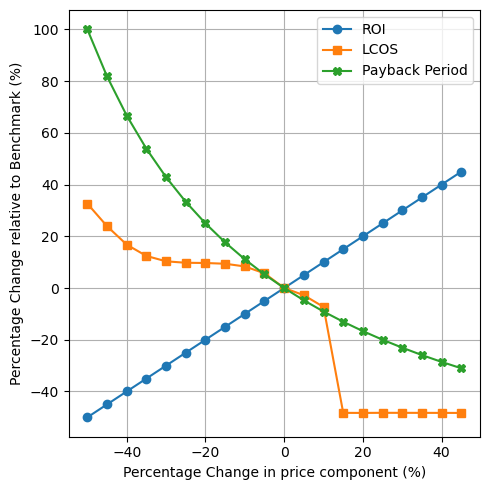

In [10]:
change_log, roi_log, lcos_log, ROI_lifetime_log, payback_period_log = np.array(change_log), np.array(roi_log), np.array(lcos_log), np.array(ROI_lifetime_log), np.array(payback_period_log)
bench_idx = np.where(change_log ==  0)[0]
bench_values = {
    'ROI': roi_log[bench_idx][0],
    'LCOS': lcos_log[bench_idx][0],
    'ROI_lifetime': ROI_lifetime_log[bench_idx][0],
    'payback_period': payback_period_log[bench_idx][0]
}

# percentage change from benchmark
roi_change = 100 * (roi_log - bench_values['ROI']) / bench_values['ROI']
lcos_change = 100 * (lcos_log - bench_values['LCOS']) / bench_values['LCOS']
ROI_lifetime_change = 100 * (ROI_lifetime_log - bench_values['ROI_lifetime']) / bench_values['ROI_lifetime']
payback_period_change = 100 * (payback_period_log - bench_values['payback_period']) / bench_values['payback_period']

# Plotting
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(change_log * 100, roi_change, marker='o')
ax.plot(change_log * 100, lcos_change, marker='s')
# ax.plot(change_log * 100, ROI_lifetime_change, marker='^')
ax.plot(change_log * 100, payback_period_change, marker='X')

# ax.legend(['ROI', 'LCOS', 'ROI (Lifetime)', 'Payback Period'])
ax.legend(['ROI', 'LCOS', 'Payback Period'])
ax.set_xlabel('Percentage Change in price component (%)')
ax.set_ylabel('Percentage Change relative to Benchmark (%)')

plt.grid()
plt.tight_layout()
plt.savefig('sens_price_subs.svg', dpi=300)
plt.show()

In [15]:
lcos_change

array([ 32.6218429 ,  23.9103425 ,  16.76906773,  12.40318335,
        10.3255613 ,   9.76332878,   9.67321392,   9.38666423,
         8.33947787,   5.69030168,   0.        ,  -2.78544363,
        -7.3119194 , -48.2729947 , -48.29788017, -48.25346342,
       -48.26529849, -48.27447326, -48.28563174, -48.30327956])